#2η ομαδική εργασία στη Τεχνολογία και Ανάλυση Εικόνων και Βίντεο

#Θεωρητικό Μέρος

Tα επίπεδα, το μέγεθος των φίλτρων, η συνάρτηση ενεργοποίησης, το πλήθος παραμέτρων και οι τεχνικές pooling και dropout που χρησιμοποιούν τα 3 διαφορετικά δίκτυα που παρουσιάζονται στα προαναφερθέντα άρθρα παρουσιάζονται στον ακόλουθο πίνακα.


| Model | Trainable Layers | Pooling Layers | Filter size | Activation Function | Parameters | Pooling |Dropout
| --- | --- | --- | --- | --- | --- | --- | --- |
| LeNet | 3 | 2 | 5x5 | Sigmoid | 2578 | Average | No
| AlexNet | 8 | 3 | 11x11, 5x5, 3x3 | ReLU |  60 million | Max |  0.5 |
| VGG-11 | 11 | 5 | 3x3 | ReLU | 133 million | Max | 0.5 only in two FC layers

Το πρώτο δίκτυο (LeNet) που δημιουργήθηκε για αναγνώριση ψηφίων σε ταχυδρομικούς κώδικες, μετά από 30 εποχές εκπαίδευσης πετυχαίνει test error rate 3.4%. Παρόλο που επιλύει ένα απλό πρόβλημα, η απόδοσή του σε σχέση με το σύνολο δεδομένων του (9298) και με βάση την εποχή την οποία δημιουργήθηκε είναι αξιοπρόσεκτη. Το δεύτερο δίκτυο (AlexNet) που δημιοηργήθηκε για ένα πολύ μεγαλύτερο σύνολο δεδομένων, το ImageNet μεγέθους 1.000.000 εικόνων, παρουσιάζει πολλές ομοιότητες με το LeNet, εκμεταλλευόμενο τις μοντέρνες τεχνικές μεγιστοποίησης απόδοσης και μείωσης υπερεκπαίδευσης, καθώς και μεγαλύτερη υπολογιστική ισχύ, επιτυγχάνει πολύ καλύτερη απόδοση. Συγκεκριμένα, επιτυγχάνει top-1 και top-5 error rate 40.7% και 18.2% αντίστοιχα. Για το επίτευγμα αυτό, απαιτεί πολλή περισσότερη υπολογιστική ισχύ και πιο βαθύ νευρωνικό δίκτυο, σε σχέση με το LeNet. Το τελευταίο δίκτυο (VGG-11) που δημιουργήθηκε για να βελτιώσει το προηγούμενο του (AlexNet), προσθέτοντας βάθος και ομαδοποιώντας επίπεδα του δικτύου σε blocks, επιτυγχάνει ακόμη καλύτερη απόδοση. Συγκεκριμένα, επιτυγχάνει top-1 και top-5 error rate 23.7% και 6.8% αντίστοιχα. Επειδή καλύτερα αποτελέσματα απαιτούν μεγαλύτερη υπολογιστική πολυπλοκότητα, διαμορφώνοντας τον αριθμό των blocks μπορεί κανείς να συμβιβαστεί μεταξύ αυτών των δύο.

#Υλοποίηση Αλγορίθμου

## Εισαγωγή και επισκόπηση του συνόλου δεδομένων

In [ ]:
from __future__ import absolute_import, division, print_function, unicode_literals # legacy compatibility

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
from sklearn.metrics import f1_score

In [ ]:
# helper functions

# select from from_list elements with index in index_list
def select_from_list(from_list, index_list):
  filtered_list= [from_list[i] for i in index_list]
  return(filtered_list)

# append in filtered_list the index of each element of unfilterd_list if it exists in in target_list
def get_ds_index(unfiliterd_list, target_list):
  index = 0
  filtered_list=[]
  for i_ in unfiliterd_list:
    if i_[0] in target_list:
      filtered_list.append(index)
    index += 1
  return(filtered_list)

In [ ]:
# load the entire dataset
import tensorflow as tf
from tensorflow.keras import datasets, layers, models

(x_train_all, y_train_all), (x_test_all, y_test_all) = tf.keras.datasets.cifar100.load_data(label_mode='fine')

In [ ]:
print(x_train_all.shape)

(50000, 32, 32, 3)


Η κάθε ομάδα θα δουλέψει με διαφορετικό υποσύνολο του dataset.
Στο επόμενο κελί, αντικαταστήστε την τιμή της μεταβλητής `team_seed` με τον αριθμό που αντιστοιχεί στην ομάδας σας.

In [ ]:
# REPLACE WITH YOUR TEAM NUMBER
team_seed = 92 # ο ΑΜ μου είναι 03121902, αλλά το 902 βγαίνει εκτός του πεδίου των τιμών του team_classes, που είναι 200. Χρησιμοποιώ το 92 αντί του 902, για να είμαι στα αποδεκτά όρια.

In [ ]:
# select from CIFAR100 20 classes
cifar100_classes_url = "https://pastebin.com/raw/nzE1n98V"

Δημιουργούμε το μοναδικό dataset της ομάδας μας:

In [ ]:
team_classes = pd.read_csv("nzE1n98V.csv", header=None)
CIFAR100_LABELS_LIST = pd.read_csv("qgDaNggt.csv", header=None).astype(str).values.tolist()[0]

our_index = team_classes.iloc[team_seed,:].values.tolist()
our_classes = select_from_list(CIFAR100_LABELS_LIST, our_index)
train_index = get_ds_index(y_train_all, our_index)
test_index = get_ds_index(y_test_all, our_index)

x_train_ds = np.asarray(select_from_list(x_train_all, train_index))
y_train_ds2 = np.asarray(select_from_list(y_train_all, train_index))
x_test_ds = np.asarray(select_from_list(x_test_all, test_index))
y_test_ds2 = np.asarray(select_from_list(y_test_all, test_index))

In [ ]:
my_dict = {}
for i, j in enumerate(our_index):
  my_dict[j] = i

y_train_ds = []
for [el] in y_train_ds2:
  y_train_ds.append([my_dict[el]])
y_train_ds = np.array(y_train_ds)

y_test_ds = []
for [el] in y_test_ds2:
  y_test_ds.append([my_dict[el]])
y_test_ds = np.array(y_test_ds)

In [ ]:
# print our classes
print(our_classes)

[' bed', ' bee', ' bottle', ' butterfly', ' chair', ' cockroach', ' crab', ' dolphin', ' kangaroo', ' orchid', ' otter', ' rabbit', ' ray', ' spider', ' squirrel', ' streetcar', ' sweet_pepper', ' table', ' tractor', ' tulip']


In [ ]:
print(x_train_ds[1].shape)

(32, 32, 3)


Train: X=(8500, 32, 32, 3), y=(8500, 1)
Validation: X=(1500, 32, 32, 3), y=(1500, 1)
Test: X=(2000, 32, 32, 3), y=(2000, 1)


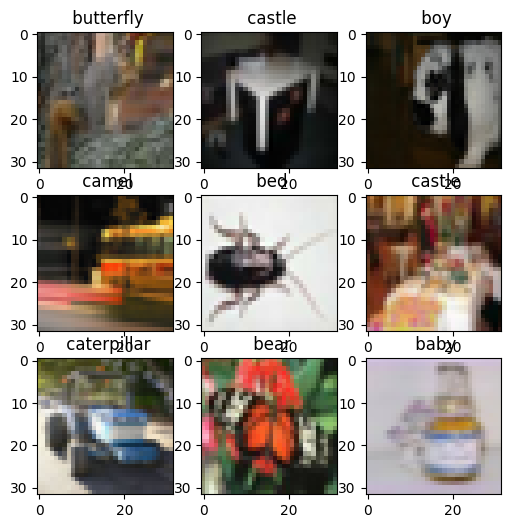

In [ ]:
# get (train) dataset dimensions
data_size, img_rows, img_cols, img_channels = x_train_ds.shape

# set validation set percentage (wrt the training set size)
validation_percentage = 0.15
val_size = round(validation_percentage * data_size)

# Reserve val_size samples for validation and normalize all values
x_val = x_train_ds[-val_size:]/255
y_val = y_train_ds[-val_size:]
x_train = x_train_ds[:-val_size]/255
y_train = y_train_ds[:-val_size]
x_test = x_test_ds/255
y_test = y_test_ds

# summarize loaded dataset
print('Train: X=%s, y=%s' % (x_train.shape, y_train.shape))
print('Validation: X=%s, y=%s' % (x_val.shape, y_val.shape))
print('Test: X=%s, y=%s' % (x_test.shape, y_test.shape))

# get class label from class index
def class_label_from_index(fine_category):
  return(CIFAR100_LABELS_LIST[fine_category.item(0)])

# plot first few images
plt.figure(figsize=(6, 6))
for i in range(9):
	# define subplot
  plt.subplot(330 + 1 + i).set_title(class_label_from_index(y_train[i]))
	# plot raw pixel data
  plt.imshow(x_train[i], cmap=plt.get_cmap('gray'))
  #show the figure
plt.show()

## Ερώτημα 1
---
### Βήμα 1: Σχεδίαση και εκπαίδευση των μοντέλων

 Σχεδίαστε και εκπαιδεύστε τα μοντέλα  **LeNet, AlexNet και  VGG**, καθώς και ένα δικό σας μοντέλο (ονομάστε το π.χ. **MyCNN**) χρησιμοποιώντας τον ίδιο αλγορίθμο βελτιστοποίησης ([optimizer](https://keras.io/api/optimizers/)), την ίδια συνάρτηση κόστους [loss function](https://keras.io/api/losses/), το ίδιο μέγεθος παρτίδας (batch size) και 50 εποχές (epochs) `*`.

 Για την εκτίμηση της απόδοσης των μοντέλων να χρησιμοποιήσετε ως μετρική ([metrics](https://keras.io/api/metrics/)) την F1-score.


`*`
 Μπορείτε να πειραματιστείτε με τον optimizer, την loss function και το batch size για τα 4 μοντέλα πριν καταλήξετε στην τελική σας κοινή, για όλα τα μοντέλα επιλογή.


---
  
### Βήμα 2: Αξιολόγηση των μοντέλων

α. Για κάθε ένα από τα μοντέλα που εκπαιδεύσατε στο Βήμα 1, απεικονίστε σε κοινό διάγραμμα τα F1-scores εκπαίδευσης και επικύρωσης στο σύνολο των εποχών.

β. Αξιολογήστε, αναλυτικά, τα αποτελέσματά σας ως προς τα εξής:
 - Επίδραση του πλήθους των δεδομένων/κλάσεων.
 - Επίδραση του αλγόριθμου βελτιστοποίησης (optimizer)
 - Επίδραση του μεγέθους δέσμης (batch size)
---

### Βήμα 3: Αξιολόγηση F1-score
Αξιολογήστε τα F1-scores, χρησιμοποιώντας το σύνολο ελέγχου σας (test set).

---

In [ ]:
def resize_batch (images, dim_x, dim_y = None, channels = 3):
  if dim_y == None:
    dim_y = dim_x
  resized = []
  for im in images:
    resized.append(cv2.resize(im, (dim_x, dim_y)))

  res = np.stack(resized)
  if channels == 1:
    res = np.expand_dims(res.mean(axis=3), axis=-1)
  return res

In [ ]:
class F1ScoreCallback(tf.keras.callbacks.Callback):
    def __init__(self, x_train, y_train, x_val, y_val):
        super().__init__()
        self.x_train = x_train
        self.y_train = y_train
        self.x_val = x_val
        self.y_val = y_val
        self.f1_scores_train = []
        self.f1_scores_val = []

    def on_epoch_end(self, epoch, logs=None):
      batch_size = 128

      y_train_pred = np.argmax(self.model.predict(self.x_train, batch_size=batch_size, verbose=0), axis=1)
      y_val_pred = np.argmax(self.model.predict(self.x_val, batch_size=batch_size, verbose=0), axis=1)

      y_train_true = self.y_train.reshape(-1)
      y_val_true = self.y_val.reshape(-1)

      f1_train = f1_score(y_train_true, y_train_pred, average='macro')
      f1_val = f1_score(y_val_true, y_val_pred, average='macro')

      self.f1_scores_train.append(f1_train)
      self.f1_scores_val.append(f1_val)

      print(f"\nEpoch {epoch+1}: F1 Train = {f1_train:.4f}, F1 Val = {f1_val:.4f}")


def evaluate_f1_score(model, x_test, y_test):
    y_pred = np.argmax(model.predict(x_test, verbose=0), axis=1)
    y_true = y_test.reshape(-1)
    f1 = f1_score(y_true, y_pred, average='macro')
    return f1

compile_params = {
    'optimizer': 'adam',
    'loss': tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    'metrics': ['accuracy']  # Keep accuracy for reference, but we'll focus on F1
}

fit_params = {
    'epochs': 50,
    'batch_size': 128
}

def plot_f1_scores(f1_train, f1_val, title):
    plt.figure(figsize=(10, 6))
    plt.plot(f1_train, label='Train F1-Score')
    plt.plot(f1_val, label='Validation F1-Score')
    plt.title(f'F1-Score - {title}')
    plt.xlabel('Epoch')
    plt.ylabel('F1-Score')
    plt.legend()
    plt.grid(True)
    plt.show()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 28, 28, 6)      │           156 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_6             │ (None, 14, 14, 6)      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 10, 10, 16)     │         2,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_7             │ (None, 5, 5, 16)       │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 400)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 120)            │        48,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 84)             │        10,164 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 20)             │         1,700 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ softmax_3 (Softmax)             │ (None, 20)             │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 62,556 (244.36 KB)

 Trainable params: 62,556 (244.36 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.0519 - loss: 3.0286
Epoch 1: F1 Train = 0.0048, F1 Val = 0.0043
67/67 ━━━━━━━━━━━━━━━━━━━━ 7s 47ms/step - accuracy: 0.0518 - loss: 3.0283 - val_accuracy: 0.0453 - val_loss: 3.0031
Epoch 2/50
66/67 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.0468 - loss: 3.0035
Epoch 2: F1 Train = 0.0047, F1 Val = 0.0053
67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.0468 - loss: 3.0035 - val_accuracy: 0.0560 - val_loss: 3.0008
Epoch 3/50
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.0524 - loss: 3.0002
Epoch 3: F1 Train = 0.0221, F1 Val = 0.0235
67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.0524 - loss: 3.0001 - val_accuracy: 0.0627 - val_loss: 2.9848
Epoch 4/50
66/67 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.0833 - loss: 2.9677
Epoch 4: F1 Train = 0.0541, F1 Val = 0.0519
67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.0834 - loss: 2.9670 - val_accuracy: 0.0940 - val_loss: 2.9032
Epoch 5/50
65/67 ━━━━━━━━

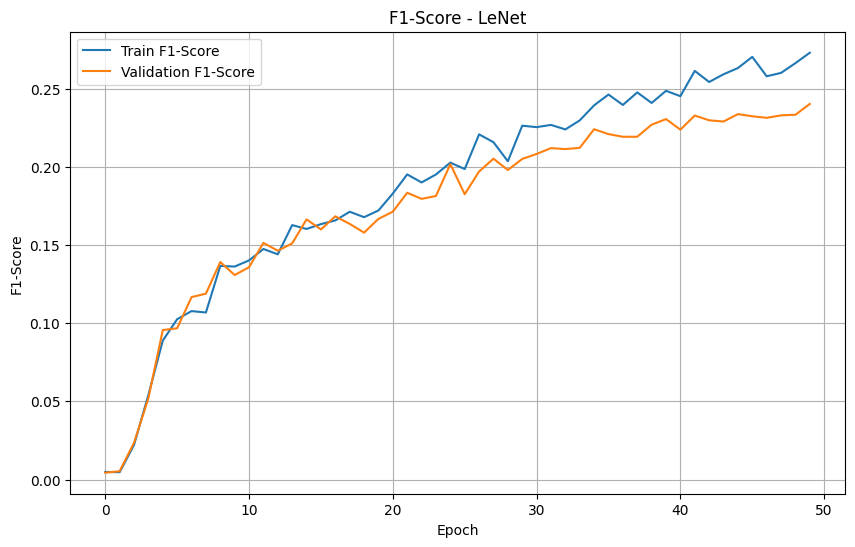

LeNet F1-Score on Test Set: 0.2404


In [ ]:
lenet = models.Sequential([
    layers.Conv2D(filters=6, kernel_size=5, strides=1, padding='same', activation='sigmoid', input_shape=(28,28,1)), # μονοχρωματική είσοδος 28x28
    layers.AvgPool2D(pool_size=2, strides=2),
    layers.Conv2D(filters=16, kernel_size=5, strides=1, padding='valid', activation='sigmoid'),
    layers.AvgPool2D(pool_size=2, strides=2),
    layers.Flatten(),
    layers.Dense(120, activation='sigmoid'),
    layers.Dense(84, activation='sigmoid'),
    layers.Dense(20),
    layers.Softmax()
])
lenet.summary()

lenet_train = resize_batch(x_train, 28, channels=1)
lenet_val = resize_batch(x_val, 28, channels=1)
lenet_test = resize_batch(x_test, 28, channels=1)

lenet_f1_callback = F1ScoreCallback(lenet_train, y_train, lenet_val, y_val)

lenet.compile(**compile_params)
lenet_history = lenet.fit(
    lenet_train, y_train,
    validation_data=(lenet_val, y_val),
    epochs=fit_params['epochs'],
    batch_size=fit_params['batch_size'],
    callbacks=[lenet_f1_callback]
)

plot_f1_scores(lenet_f1_callback.f1_scores_train, lenet_f1_callback.f1_scores_val, 'LeNet')

lenet_f1 = evaluate_f1_score(lenet, lenet_test, y_test)
print(f"LeNet F1-Score on Test Set: {lenet_f1:.4f}")

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_21 (Conv2D)              │ (None, 15, 15, 96)     │        34,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 7, 7, 96)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_22 (Conv2D)              │ (None, 7, 7, 256)      │       614,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 3, 3, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_23 (Conv2D)              │ (None, 3, 3, 384)      │       885,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_24 (Conv2D)              │ (None, 3, 3, 384)      │     1,327,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_25 (Conv2D)              │ (None, 3, 3, 256)      │       884,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 1, 1, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 4096)           │     1,052,672 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 20)             │        81,940 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ softmax_6 (Softmax)             │ (None, 20)             │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,663,124 (82.64 MB)

 Trainable params: 21,663,124 (82.64 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 0.0517 - loss: 2.9937
Epoch 1: F1 Train = 0.0047, F1 Val = 0.0052
67/67 ━━━━━━━━━━━━━━━━━━━━ 14s 142ms/step - accuracy: 0.0517 - loss: 2.9935 - val_accuracy: 0.0547 - val_loss: 2.9955
Epoch 2/50
65/67 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.0710 - loss: 2.9443
Epoch 2: F1 Train = 0.0616, F1 Val = 0.0568
67/67 ━━━━━━━━━━━━━━━━━━━━ 4s 65ms/step - accuracy: 0.0719 - loss: 2.9412 - val_accuracy: 0.1067 - val_loss: 2.7607
Epoch 3/50
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.1157 - loss: 2.7629
Epoch 3: F1 Train = 0.0955, F1 Val = 0.0936
67/67 ━━━━━━━━━━━━━━━━━━━━ 4s 59ms/step - accuracy: 0.1158 - loss: 2.7624 - val_accuracy: 0.1247 - val_loss: 2.7082
Epoch 4/50
65/67 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.1323 - loss: 2.6748
Epoch 4: F1 Train = 0.0838, F1 Val = 0.0759
67/67 ━━━━━━━━━━━━━━━━━━━━ 4s 59ms/step - accuracy: 0.1320 - loss: 2.6751 - val_accuracy: 0.1253 - val_loss: 2.6781
Epoch 5/50
67/67 ━

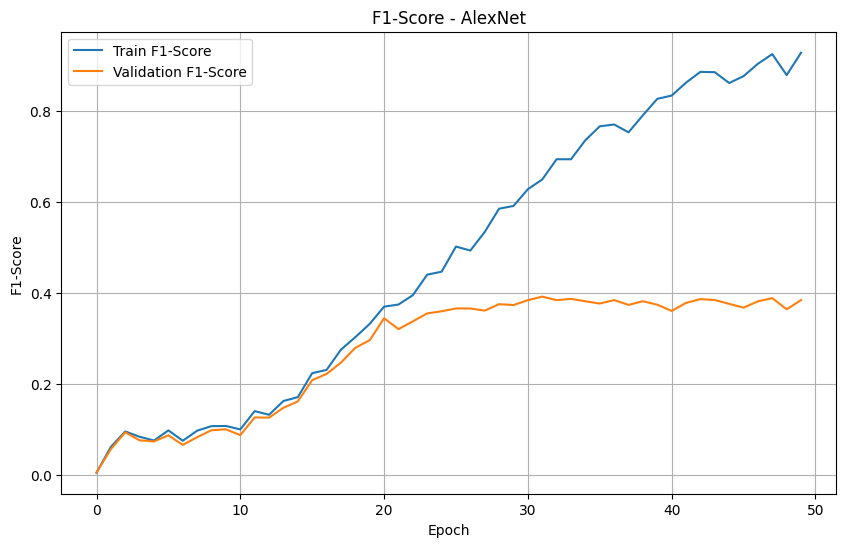

AlexNet F1-Score on Test Set: 0.3899


In [ ]:
alexnet_train = resize_batch(x_train, 70)
alexnet_val = resize_batch(x_val, 70)
alexnet_test = resize_batch(x_test, 70)

alexnet = models.Sequential([
    layers.Conv2D(filters=96, kernel_size=11, strides=4, activation='relu', input_shape=(70,70,3)), # 70x70 αντί για 224x224 λόγω περιορισμένων πόρων μνήμης του colab
    layers.MaxPool2D(pool_size=3, strides=2),
    layers.Conv2D(filters=256, kernel_size=5, padding='same', activation='relu'),
    layers.MaxPool2D(pool_size=3, strides=2),
    layers.Conv2D(filters=384, kernel_size=3, padding='same', activation='relu'),
    layers.Conv2D(filters=384, kernel_size=3, padding='same', activation='relu'),
    layers.Conv2D(filters=256, kernel_size=3, padding='same', activation='relu'),
    layers.MaxPool2D(pool_size=3, strides=2),
    layers.Flatten(),
    layers.Dense(4096, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(4096, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(20),
    layers.Softmax()
])
alexnet.summary()

alexnet_f1_callback = F1ScoreCallback(alexnet_train, y_train, alexnet_val, y_val)

alexnet.compile(**compile_params)
alexnet_history = alexnet.fit(
    alexnet_train, y_train,
    validation_data=(alexnet_val, y_val),
    epochs=fit_params['epochs'],
    batch_size=fit_params['batch_size'],
    callbacks=[alexnet_f1_callback]
)

plot_f1_scores(alexnet_f1_callback.f1_scores_train, alexnet_f1_callback.f1_scores_val, 'AlexNet')

alexnet_f1 = evaluate_f1_score(alexnet, alexnet_test, y_test)
print(f"AlexNet F1-Score on Test Set: {alexnet_f1:.4f}")

Model: "sequential_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_14 (Sequential)      │ (None, 35, 35, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_15 (Sequential)      │ (None, 17, 17, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_16 (Sequential)      │ (None, 8, 8, 256)      │       885,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_17 (Sequential)      │ (None, 4, 4, 512)      │     3,539,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_18 (Sequential)      │ (None, 2, 2, 512)      │     4,719,616 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_19 (Sequential)      │ (None, 20)             │    25,255,956 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,476,436 (131.52 MB)

 Trainable params: 34,476,436 (131.52 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 167ms/step - accuracy: 0.0476 - loss: 3.0042
Epoch 1: F1 Train = 0.0051, F1 Val = 0.0042
67/67 ━━━━━━━━━━━━━━━━━━━━ 27s 314ms/step - accuracy: 0.0476 - loss: 3.0041 - val_accuracy: 0.0440 - val_loss: 2.9961
Epoch 2/50
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step - accuracy: 0.0785 - loss: 2.9002
Epoch 2: F1 Train = 0.0764, F1 Val = 0.0699
67/67 ━━━━━━━━━━━━━━━━━━━━ 33s 243ms/step - accuracy: 0.0788 - loss: 2.8992 - val_accuracy: 0.1147 - val_loss: 2.7527
Epoch 3/50
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step - accuracy: 0.1266 - loss: 2.6566
Epoch 3: F1 Train = 0.0868, F1 Val = 0.0974
67/67 ━━━━━━━━━━━━━━━━━━━━ 20s 239ms/step - accuracy: 0.1267 - loss: 2.6565 - val_accuracy: 0.1533 - val_loss: 2.6538
Epoch 4/50
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step - accuracy: 0.1373 - loss: 2.6048
Epoch 4: F1 Train = 0.1129, F1 Val = 0.1145
67/67 ━━━━━━━━━━━━━━━━━━━━ 20s 240ms/step - accuracy: 0.1374 - loss: 2.6045 - val_accuracy: 0.1813 - val_loss: 2.5614
Epoch 5/

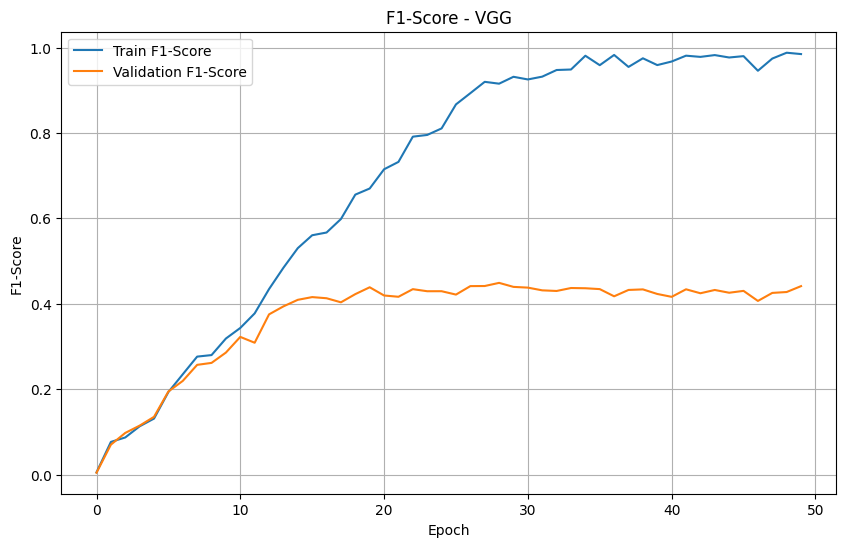

VGG F1-Score on Test Set: 0.4693


In [ ]:
vgg_train = resize_batch(x_train, 70) # 70x70 αντί για 224x224 λόγω περιορισμένων πόρων μνήμης του colab
vgg_val = resize_batch(x_val, 70)
vgg_test = resize_batch(x_test, 70)

def vgg_block(num_convs, num_channels):
    blk = models.Sequential()
    for _ in range(num_convs):
        blk.add(layers.Conv2D(num_channels, kernel_size=3, padding='same', activation='relu'))
    blk.add(layers.MaxPool2D(pool_size=2, strides=2))
    return blk

vgg = models.Sequential()
arch = [(1, 64), (1, 128), (2, 256), (2, 512), (2, 512)]
for (num_convs, num_channels) in arch:
    vgg.add(vgg_block(num_convs, num_channels))
vgg.add(models.Sequential([
    layers.Flatten(),
    layers.Dense(4096, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(4096, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(20),
    layers.Softmax()
]))
vgg.build((None, 70, 70, 3))
vgg.summary()

vgg_f1_callback = F1ScoreCallback(vgg_train, y_train, vgg_val, y_val)

vgg.compile(**compile_params)
vgg_history = vgg.fit(
    vgg_train, y_train,
    validation_data=(vgg_val, y_val),
    epochs=fit_params['epochs'],
    batch_size=fit_params['batch_size'],
    callbacks=[vgg_f1_callback]
)

plot_f1_scores(vgg_f1_callback.f1_scores_train, vgg_f1_callback.f1_scores_val, 'VGG')

vgg_f1 = evaluate_f1_score(vgg, vgg_test, y_test)
print(f"VGG F1-Score on Test Set: {vgg_f1:.4f}")

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_20"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_34 (Conv2D)              │ (None, 28, 28, 32)     │         2,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_21 (Sequential)      │ (None, 14, 14, 32)     │        27,744 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_22 (Sequential)      │ (None, 7, 7, 32)       │        55,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_8 (Flatten)             │ (None, 1568)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 16)             │        25,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 20)             │           340 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ softmax_8 (Softmax)             │ (None, 20)             │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 111,108 (434.02 KB)

 Trainable params: 111,108 (434.02 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.0627 - loss: 2.9785
Epoch 1: F1 Train = 0.0836, F1 Val = 0.0840
67/67 ━━━━━━━━━━━━━━━━━━━━ 12s 98ms/step - accuracy: 0.0629 - loss: 2.9780 - val_accuracy: 0.1187 - val_loss: 2.8487
Epoch 2/50
65/67 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.1366 - loss: 2.7984
Epoch 2: F1 Train = 0.1516, F1 Val = 0.1368
67/67 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - accuracy: 0.1377 - loss: 2.7961 - val_accuracy: 0.1927 - val_loss: 2.6622
Epoch 3/50
65/67 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.2169 - loss: 2.5799
Epoch 3: F1 Train = 0.1926, F1 Val = 0.1884
67/67 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - accuracy: 0.2173 - loss: 2.5785 - val_accuracy: 0.2287 - val_loss: 2.5755
Epoch 4/50
65/67 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.2510 - loss: 2.4796
Epoch 4: F1 Train = 0.2440, F1 Val = 0.2354
67/67 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - accuracy: 0.2513 - loss: 2.4775 - val_accuracy: 0.2733 - val_loss: 2.3927
Epoch 5/50
65/67 ━━

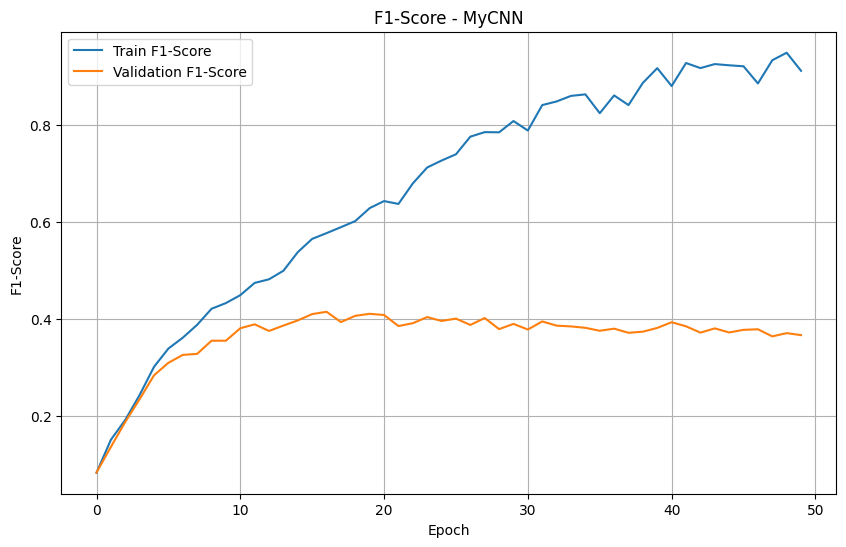

MyCNN F1-Score on Test Set: 0.3906


In [ ]:
mycnn_train = resize_batch(x_train, 32)
mycnn_val = resize_batch(x_val, 32)
mycnn_test = resize_batch(x_test, 32)

def my_block(num_convs):
    blk = models.Sequential()
    for _ in range(num_convs):
        blk.add(layers.Conv2D(filters=32, kernel_size=3, padding='same', activation='relu'))
    blk.add(layers.MaxPool2D(pool_size=2, strides=2))
    return blk

mycnn = models.Sequential([
    layers.Conv2D(filters=32, kernel_size=5, padding='valid', activation='relu', input_shape=(32,32,3))
])
mycnn.add(my_block(3))
mycnn.add(my_block(6))
mycnn.add(layers.Flatten())
mycnn.add(layers.Dense(16, activation='relu'))
mycnn.add(layers.Dense(20))
mycnn.add(layers.Softmax())
mycnn.summary()

mycnn_f1_callback = F1ScoreCallback(mycnn_train, y_train, mycnn_val, y_val)

mycnn.compile(**compile_params)
mycnn_history = mycnn.fit(
    mycnn_train, y_train,
    validation_data=(mycnn_val, y_val),
    epochs=fit_params['epochs'],
    batch_size=fit_params['batch_size'],
    callbacks=[mycnn_f1_callback]
)

plot_f1_scores(mycnn_f1_callback.f1_scores_train, mycnn_f1_callback.f1_scores_val, 'MyCNN')

mycnn_f1 = evaluate_f1_score(mycnn, mycnn_test, y_test)
print(f"MyCNN F1-Score on Test Set: {mycnn_f1:.4f}")

Το μοντέλο MyCNN που δημιούργησα ακολουθεί την αρχιτεκτονική του καλύτερου μοντέλου από τα 3 άρθρα, το VGG, με 1 συνελικτικό επίπεδο φίλτρου 5x5 και 2 blocks μεγέθους 3 και 6 συνελικτικών επιπέδων, με τα στοιχεία της κλασσικής αρχιτεκτονικής VGG. Τα υπόλοιπα επίπεδα ακολουθούν επίσης την αρχιτεκτονική των τελευταίων επίπεδων του μοντέλου VGG. Ως αλγόριθμο βελτιστοποίησης χρησιμοποιούμε τον Adam, ως συνάρτηση κόστους την CrossEntropy Loss και ως batch size=128.

Στον ακόλουθο πίνακα φαίνονται τα f1 scores για όλα τα μοντέλα:

| Set | LeNet | AlexNet | VGG | MyCNN |
| --- | --- | --- | --- | --- |
| Training | 0.2729 | 0.9289 | 0.9879 | 0.9497 |
| Validation | 0.2402 | 0.3888 | 0.4413 | 0.3956 |
| Test | 0.2404 | 0.3899 | 0.4693 | 0.3906 |


Παρατηρούμε πως η απόδοση των μοντέλων αυξάνεται όσο το μοντέλο γίνεται πιο σύγχρονο και πολύπλοκο. Ωστόσο, προς αυτή την κατεύθυνση αυξάνεται ραγδαία η διαφορά training και validation set f1 score, το οποίο δείχνει οτι τα πολύπλοκα μοντέλα υπερεκπαιδεύονται στο σύνολο των δεδομένων και δυσκολεύονται έτσι να γενικεύσουν. Όσο αυξάνεται το πλήθος των δεδομένων, τόσο αυξάνεται η απόδοση των μοντέλων, καθώς έχουν δεί περισσότερα δείγματα από τις κλάσεις και έτσι αυξάνονται οι πιθανότητες σωστής ταξινόμησης. Αναφορικά με το πλήθος των κλάσεων, όσο αυτές αυξάνονται, τόσο αυξάνονται οι πιθανότητες λάθους ταξινόμησης από τα μοντέλα, οπότε η απόδοση μειώνεται. Η επιλογή του αλγορίθμου βελτιστοποίησης δεν έχει σημαντική επιρροή στην απόδοση, καθώς παρουσιάζει ελαφρά καλύτερη απόδοση από άλλους, όπως το SGD. Η διαφορά αυτή μπορεί να οφείλεται στο ότι ο Adam επιταχύνει τη σύγκλιση και τροποποιεί κατάλληλα το ρυθμό μάθησης. Όσον αφορά το batch size, μικρότερο batch size γενικά έχει καλύτερη απόδοση στα μοντέλα. Χρησιμοποιούμε αρκετά μεγάλο, για να γλιτώσουμε χρόνο εκπαίδευσης, καθώς αυτός αυξάνεται πολύ με τη μείωση του μεγέθους του batch.


## Ερώτημα 2
---
### Βήμα 1: Έλεγχος υπερεκπαίδευσης

Για μοντέλο σας  (**MyCNN**) και μόνο, δοκιμάστε διάφορους συνδυασμούς των ακόλουθων τεχνικών για τον έλεγχο της υπερεκπαίδευσης (overfitting), ώστε το μοντέλο σας να γενικεύει καλύτερα, όπως:

- Dropout ([Dropout](https://www.tensorflow.org/tutorials/images/classification#dropout))

- Επαύξηση δεδομένων ([Data augmentation](https://www.tensorflow.org/tutorials/images/classification#data_augmentation), [ImageDataGenerator](https://www.tensorflow.org/api_docs/python/tf/keras/preprocessing/image/ImageDataGenerator#class_imagedatagenerator))

---
### Βήμα 2: Αξιολόγηση
Αξιολογήστε τα αποτελέσματά σας, βάσει του F1 score για το σύνολο επικύρωσης και για το σύνολο ελέγχου

---


/usr/local/lib/python3.11/dist-packages/keras/src/layers/preprocessing/tf_data_layer.py:19: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_4 (Sequential)       │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 28, 28, 32)     │         2,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_5 (Sequential)       │ (None, 14, 14, 32)     │        27,744 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_6 (Sequential)       │ (None, 7, 7, 32)       │        55,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1568)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1568)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │        25,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 20)             │           340 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ softmax_1 (Softmax)             │ (None, 20)             │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 111,108 (434.02 KB)

 Trainable params: 111,108 (434.02 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
65/67 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.0548 - loss: 2.9915
Epoch 1: F1 Train = 0.0391, F1 Val = 0.0338
67/67 ━━━━━━━━━━━━━━━━━━━━ 7s 41ms/step - accuracy: 0.0550 - loss: 2.9910 - val_accuracy: 0.0907 - val_loss: 2.9417
Epoch 2/50
66/67 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.0722 - loss: 2.9449
Epoch 2: F1 Train = 0.0519, F1 Val = 0.0544
67/67 ━━━━━━━━━━━━━━━━━━━━ 5s 43ms/step - accuracy: 0.0723 - loss: 2.9444 - val_accuracy: 0.0967 - val_loss: 2.8411
Epoch 3/50
66/67 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.1008 - loss: 2.8456
Epoch 3: F1 Train = 0.0909, F1 Val = 0.0920
67/67 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - accuracy: 0.1009 - loss: 2.8452 - val_accuracy: 0.1333 - val_loss: 2.7459
Epoch 4/50
64/67 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.1051 - loss: 2.7901
Epoch 4: F1 Train = 0.1110, F1 Val = 0.1203
67/67 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - accuracy: 0.1057 - loss: 2.7893 - val_accuracy: 0.1620 - val_loss: 2.6655
Epoch 5/50
64/67 ━━━

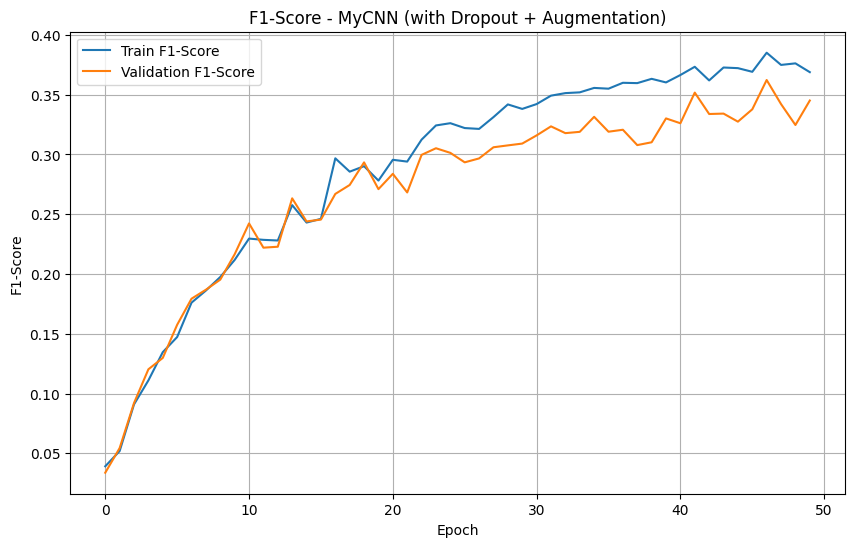

MyCNN F1-Score on Test Set: 0.3373


In [ ]:
mycnn_train = resize_batch(x_train, 32)
mycnn_val = resize_batch(x_val, 32)
mycnn_test = resize_batch(x_test, 32)

data_augmentation = models.Sequential([
    layers.RandomFlip("horizontal", input_shape=(32, 32, 3)),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

def my_block(num_convs):
    blk = models.Sequential()
    for _ in range(num_convs):
        blk.add(layers.Conv2D(filters=32, kernel_size=3, padding='same', activation='relu'))
    blk.add(layers.MaxPool2D(pool_size=2, strides=2))
    return blk

mycnn = models.Sequential([
    data_augmentation,
    layers.Conv2D(filters=32, kernel_size=5, padding='valid', activation='relu', input_shape=(32,32,3)),
    my_block(3),
    my_block(6),
    layers.Flatten(),
    layers.Dropout(0.2),
    layers.Dense(16, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(20),
    layers.Softmax()
])
mycnn.summary()

mycnn_f1_callback = F1ScoreCallback(mycnn_train, y_train, mycnn_val, y_val)

mycnn.compile(**compile_params)
mycnn_history = mycnn.fit(
    mycnn_train, y_train,
    validation_data=(mycnn_val, y_val),
    epochs=fit_params['epochs'],
    batch_size=fit_params['batch_size'],
    callbacks=[mycnn_f1_callback]
)

plot_f1_scores(mycnn_f1_callback.f1_scores_train, mycnn_f1_callback.f1_scores_val, 'MyCNN (with Dropout + Augmentation)')

mycnn_f1 = evaluate_f1_score(mycnn, mycnn_test, y_test)
print(f"MyCNN F1-Score on Test Set: {mycnn_f1:.4f}")

Χρησιμοποιώντας τις τεχνικές Dropout και Data Augmentation για τη μείωση του overfitting, παρατηρούμε ότι όντως το μοντέλο γενικεύει καλύτερα. Αυτό συμβαίνει διότι οι δύο τεχνικές βοηθούν το μοντέλο να γενικεύει ως εξής. Το Dropout "νεκρώνει" κάποιους νευρώνες των συνελικτικών επιπέδων πριν τα πλήρως συνδεδεμένα επίπεδα τυχαία σε κάθε εποχή εκπαίδευσης, με αποτέλεσμα σε κάθε εποχή να προπονούνται "διαφορετικά" δίκτυα και να μην υπάρχει επικάλυψη στο τι μαθαίνει ο κάθε νευρώνας με τους υπόλοιπους, εξασφαλίζοντας έτσι κανονικοποίηση. Το Data Augmentation και συγκεκριμένα αντανάκλαση, περιστροφή και μεγέθυνση των εικόνων εισόδου προσφέρει στο μοντέλο περισσότερες και διαφορετικές εικόνες για να εκπαιδευτεί το μοντέλο, βοηθώντας έτσι την ικανότητα του να γενικεύει. Αυτή η ικανότητα γενίκευσης φαίνεται από το διάγραμμα των καμπυλών f1 scores training και validation, που σε αντίθεση με το διάγραμμα του 1ου ερωτήματος, σχεδόν ταυτίζονται.

## Ερώτημα 3
---
### Βήμα 1: Μεταφορά γνώσης
Εφαρμόστε μεταφορά γνώσης (transfer learning) στο δικό σας μοντέλο (**MyCNN**), που αξιολογήσατε ως καλύτερο προς το F1 score στην αντιμετώπιση της υπερεκπαίδεσης.

Για το transfer learning, επιλέξτε το [VGG19](https://www.tensorflow.org/api_docs/python/tf/keras/applications/vgg19)  και το [EfficientNetB0](https://www.tensorflow.org/api_docs/python/tf/keras/applications/efficientnet/EfficientNetB0) για μεταφορά μάθησης.

α. "Παγώστε" τη συνελικτική βάση και εκπαιδεύστε την κεφαλή ταξινόμησης (classification head - σημαία trainable = False).  

β. Εκπαιδέστε μόνο ένα ποσοστό των επιπέδων, το οποίο βρίσκεται προς την έξοδο του δικτύου. Οι σημαίες trainable εδώ θα πρέπει να οριστούν ανά επίπεδο.

---
### Βήμα 2: Αξιολόγηση

Αξιολογήστε τα αποτελέσματά σας, βάσει του F1 score για το σύνολο επικύρωσης και για το σύνολο ελέγχου.

---

80134624/80134624 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/50
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step - accuracy: 0.2415 - loss: 2.4946
Epoch 1: F1 Train = 0.4387, F1 Val = 0.4028
67/67 ━━━━━━━━━━━━━━━━━━━━ 35s 419ms/step - accuracy: 0.2429 - loss: 2.4900 - val_accuracy: 0.4247 - val_loss: 1.8744
Epoch 2/50
66/67 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - accuracy: 0.4882 - loss: 1.6661
Epoch 2: F1 Train = 0.5403, F1 Val = 0.4663
67/67 ━━━━━━━━━━━━━━━━━━━━ 15s 221ms/step - accuracy: 0.4885 - loss: 1.6649 - val_accuracy: 0.4727 - val_loss: 1.6846
Epoch 3/50
66/67 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - accuracy: 0.5430 - loss: 1.4608
Epoch 3: F1 Train = 0.5809, F1 Val = 0.4967
67/67 ━━━━━━━━━━━━━━━━━━━━ 25s 296ms/step - accuracy: 0.5431 - loss: 1.4602 - val_accuracy: 0.5047 - val_loss: 1.5823
Epoch 4/50
66/67 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - accuracy: 0.5909 - loss: 1.3223
Epoch 4: F1 Train = 0.6166, F1 Val = 0.5245
67/67 ━━━━━━━━━━━━━━━━━━━━ 16s 227ms/step - accuracy: 0.5908 - loss: 1.3220 - 

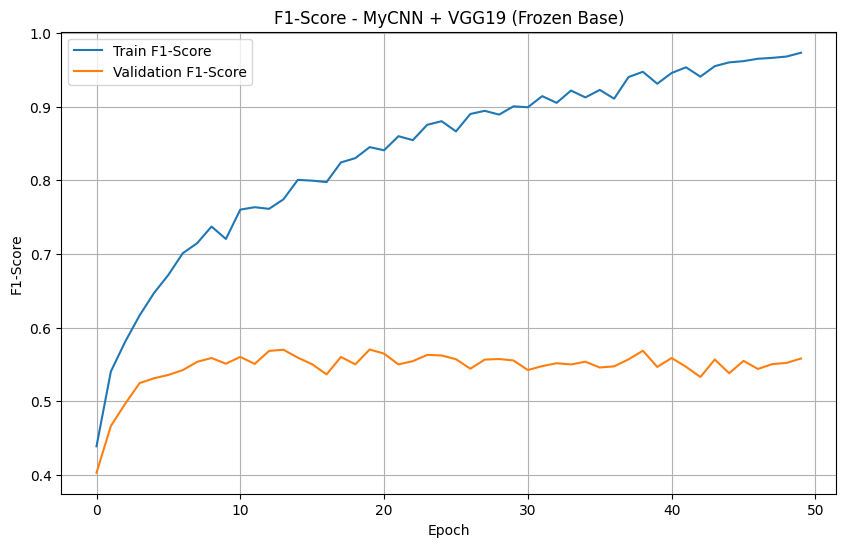

MyCNN + VGG19 (Frozen) F1-Score on Test Set: 0.5602


In [ ]:
backbone = tf.keras.applications.VGG19(
    include_top=False, weights='imagenet', input_shape=(64, 64, 3)
)
backbone.trainable = False

my_model = models.Sequential([
    backbone,
    layers.Flatten(),
    layers.Dense(100, activation='relu'),
    layers.Dense(20),
    layers.Softmax()
])

my_model_train = resize_batch(x_train, 64)
my_model_val = resize_batch(x_val, 64)
my_model_test = resize_batch(x_test, 64)

my_model_f1_callback = F1ScoreCallback(my_model_train, y_train, my_model_val, y_val)

my_model.compile(**compile_params)
my_model_history = my_model.fit(
    my_model_train, y_train,
    validation_data=(my_model_val, y_val),
    epochs=fit_params['epochs'],
    batch_size=fit_params['batch_size'],
    callbacks=[my_model_f1_callback]
)

plot_f1_scores(my_model_f1_callback.f1_scores_train, my_model_f1_callback.f1_scores_val, 'MyCNN + VGG19 (Frozen Base)')

my_model_f1 = evaluate_f1_score(my_model, my_model_test, y_test)
print(f"MyCNN + VGG19 (Frozen) F1-Score on Test Set: {my_model_f1:.4f}")

Epoch 1/50
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step - accuracy: 0.1194 - loss: 2.8421
Epoch 1: F1 Train = 0.3423, F1 Val = 0.3097
67/67 ━━━━━━━━━━━━━━━━━━━━ 32s 404ms/step - accuracy: 0.1206 - loss: 2.8375 - val_accuracy: 0.3393 - val_loss: 1.9908
Epoch 2/50
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step - accuracy: 0.4165 - loss: 1.7788
Epoch 2: F1 Train = 0.5384, F1 Val = 0.4891
67/67 ━━━━━━━━━━━━━━━━━━━━ 32s 315ms/step - accuracy: 0.4172 - loss: 1.7767 - val_accuracy: 0.5113 - val_loss: 1.5166
Epoch 3/50
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step - accuracy: 0.5807 - loss: 1.2724
Epoch 3: F1 Train = 0.6773, F1 Val = 0.5722
67/67 ━━━━━━━━━━━━━━━━━━━━ 36s 238ms/step - accuracy: 0.5809 - loss: 1.2718 - val_accuracy: 0.5700 - val_loss: 1.3081
Epoch 4/50
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step - accuracy: 0.6737 - loss: 0.9759
Epoch 4: F1 Train = 0.7417, F1 Val = 0.5949
67/67 ━━━━━━━━━━━━━━━━━━━━ 21s 311ms/step - accuracy: 0.6737 - loss: 0.9760 - val_accuracy: 0.5980 - val_loss: 1.2779
Epoch 5/

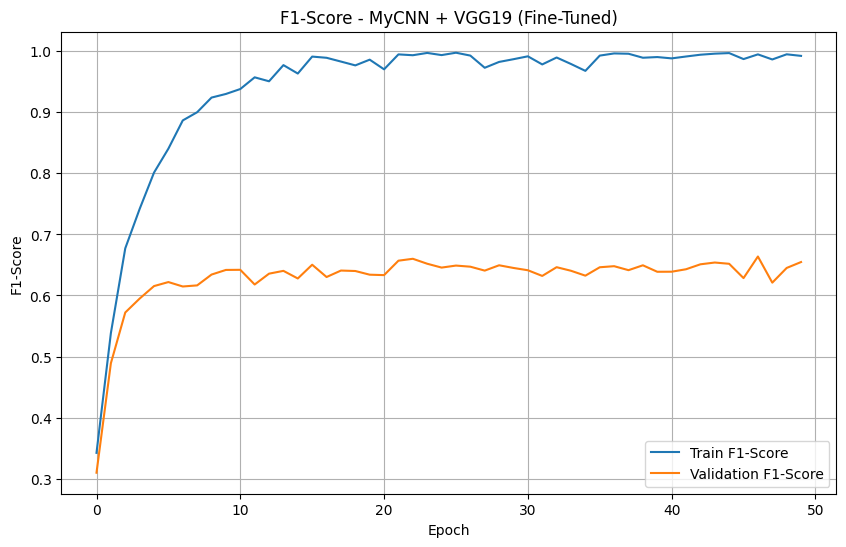

MyCNN + VGG19 (Fine-Tuned) F1-Score on Test Set: 0.6536


In [ ]:
backbone = tf.keras.applications.VGG19(
    include_top=False, weights='imagenet', input_shape=(64, 64, 3)
)

for layer in backbone.layers[:-4]:
    layer.trainable = False
for layer in backbone.layers[-4:]:
    layer.trainable = True

fine_tuned_model = models.Sequential([
    backbone,
    layers.Flatten(),
    layers.Dense(100, activation='relu'),
    layers.Dense(20),
    layers.Softmax()
])

ft_train = resize_batch(x_train, 64)
ft_val = resize_batch(x_val, 64)
ft_test = resize_batch(x_test, 64)

ft_f1_callback = F1ScoreCallback(ft_train, y_train, ft_val, y_val)

fine_tuned_model.compile(**compile_params)
ft_history = fine_tuned_model.fit(
    ft_train, y_train,
    validation_data=(ft_val, y_val),
    epochs=fit_params['epochs'],
    batch_size=fit_params['batch_size'],
    callbacks=[ft_f1_callback]
)

plot_f1_scores(ft_f1_callback.f1_scores_train, ft_f1_callback.f1_scores_val, 'MyCNN + VGG19 (Fine-Tuned)')

ft_f1 = evaluate_f1_score(fine_tuned_model, ft_test, y_test)
print(f"MyCNN + VGG19 (Fine-Tuned) F1-Score on Test Set: {ft_f1:.4f}")

Epoch 1/50
1063/1063 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.3208 - loss: 2.3632
Epoch 1: F1 Train = 0.7603, F1 Val = 0.7236
1063/1063 ━━━━━━━━━━━━━━━━━━━━ 87s 57ms/step - accuracy: 0.3209 - loss: 2.3627 - val_accuracy: 0.7240 - val_loss: 1.0012
Epoch 2/50
1061/1063 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6930 - loss: 1.0355
Epoch 2: F1 Train = 0.8139, F1 Val = 0.7506
1063/1063 ━━━━━━━━━━━━━━━━━━━━ 21s 14ms/step - accuracy: 0.6930 - loss: 1.0354 - val_accuracy: 0.7493 - val_loss: 0.7864
Epoch 3/50
1062/1063 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7399 - loss: 0.8344
Epoch 3: F1 Train = 0.8413, F1 Val = 0.7661
1063/1063 ━━━━━━━━━━━━━━━━━━━━ 14s 14ms/step - accuracy: 0.7399 - loss: 0.8343 - val_accuracy: 0.7647 - val_loss: 0.7170
Epoch 4/50
1062/1063 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7729 - loss: 0.7185
Epoch 4: F1 Train = 0.8619, F1 Val = 0.7780
1063/1063 ━━━━━━━━━━━━━━━━━━━━ 16s 15ms/step - accuracy: 0.7729 - loss: 0.7185 - val_accuracy: 0.7780 - val_

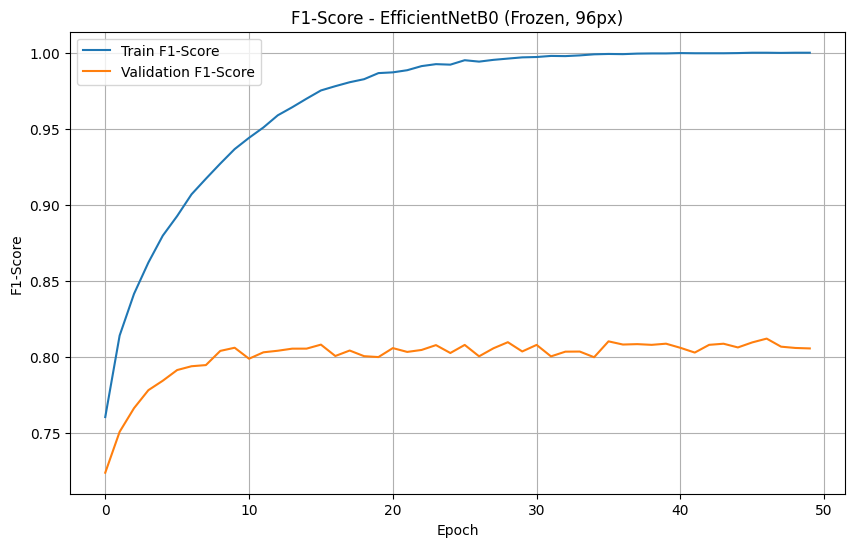

Frozen Backbone Test F1: 0.8230


In [ ]:
import tensorflow as tf
from tensorflow.keras import models, layers, optimizers
from tensorflow.keras.applications.efficientnet import EfficientNetB0, preprocess_input

train_96 = preprocess_input(resize_batch(x_train, 96) * 255.0)
val_96   = preprocess_input(resize_batch(x_val,   96) * 255.0)
test_96  = preprocess_input(resize_batch(x_test,  96) * 255.0)

backbone = EfficientNetB0(
    include_top=False,
    weights='imagenet',
    input_shape=(96, 96, 3)
)
backbone.trainable = False

frozen_model = models.Sequential([
    backbone,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(20, activation='softmax'),
])

opt = optimizers.Adam(1e-4)
frozen_model.compile(
    optimizer=opt,
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

frozen_cb = F1ScoreCallback(train_96, y_train, val_96, y_val)
frozen_history = frozen_model.fit(
    train_96, y_train,
    validation_data=(val_96, y_val),
    epochs=50,
    batch_size=8,
    callbacks=[frozen_cb]
)

plot_f1_scores(
    frozen_cb.f1_scores_train,
    frozen_cb.f1_scores_val,
    'EfficientNetB0 (Frozen, 96px)'
)
print(f"Frozen Backbone Test F1: {evaluate_f1_score(frozen_model, test_96, y_test):.4f}")

Epoch 1/50
1063/1063 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.0753 - loss: 3.0940
Epoch 1: F1 Train = 0.2491, F1 Val = 0.2439
1063/1063 ━━━━━━━━━━━━━━━━━━━━ 125s 90ms/step - accuracy: 0.0753 - loss: 3.0938 - val_accuracy: 0.2687 - val_loss: 2.6262
Epoch 2/50
1062/1063 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.2239 - loss: 2.6293
Epoch 2: F1 Train = 0.4788, F1 Val = 0.4701
1063/1063 ━━━━━━━━━━━━━━━━━━━━ 51s 20ms/step - accuracy: 0.2240 - loss: 2.6291 - val_accuracy: 0.4987 - val_loss: 2.1393
Epoch 3/50
1059/1063 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.4068 - loss: 2.1711
Epoch 3: F1 Train = 0.5984, F1 Val = 0.5736
1063/1063 ━━━━━━━━━━━━━━━━━━━━ 39s 17ms/step - accuracy: 0.4069 - loss: 2.1707 - val_accuracy: 0.5933 - val_loss: 1.7119
Epoch 4/50
1059/1063 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.4837 - loss: 1.8410
Epoch 4: F1 Train = 0.6677, F1 Val = 0.6330
1063/1063 ━━━━━━━━━━━━━━━━━━━━ 22s 19ms/step - accuracy: 0.4838 - loss: 1.8407 - val_accuracy: 0.6467 - 

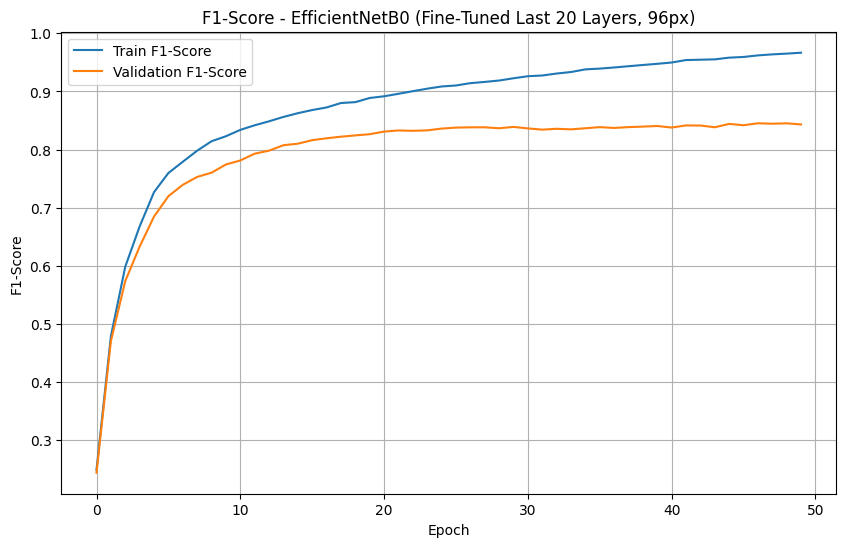

Fine‑Tuned Test F1: 0.8496


In [ ]:
from tensorflow.keras import models, layers, optimizers
from tensorflow.keras.applications.efficientnet import EfficientNetB0, preprocess_input

ft_train = preprocess_input(resize_batch(x_train, 96) * 255.0)
ft_val   = preprocess_input(resize_batch(x_val,   96) * 255.0)
ft_test  = preprocess_input(resize_batch(x_test,  96) * 255.0)

backbone = EfficientNetB0(
    include_top=False,
    weights='imagenet',
    input_shape=(96, 96, 3)
)

for layer in backbone.layers[:-20]:
    layer.trainable = False
for layer in backbone.layers[-20:]:
    layer.trainable = True

fine_tune_model = models.Sequential([
    backbone,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(20, activation='softmax'),
])

opt_ft = optimizers.Adam(1e-5)
fine_tune_model.compile(
    optimizer=opt_ft,
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

ft_cb = F1ScoreCallback(ft_train, y_train, ft_val, y_val)
ft_history = fine_tune_model.fit(
    ft_train, y_train,
    validation_data=(ft_val, y_val),
    epochs=50,
    batch_size=8,
    callbacks=[ft_cb]
)

plot_f1_scores(
    ft_cb.f1_scores_train,
    ft_cb.f1_scores_val,
    'EfficientNetB0 (Fine‑Tuned Last 20 Layers, 96px)'
)
print(f"Fine‑Tuned Test F1: {evaluate_f1_score(fine_tune_model, ft_test, y_test):.4f}")

Εφαρμόζουμε μεταφορά μάθησης στο μοντέλο μας MyCNN, χρησιμοποιώντας ως βάση τα μοντέλα VGG19 και EfficientNetB0. Στα μοντέλα αυτά εκπαιδεύουμε μία φορά μόνο το επίπεδο ταξινόμησης και μία φορά κάποια τελευταία επίπεδα μαζί με την κεφαλή ταξινόμησης (συγκεκριμένα τα 4 τελευταία για το VGG19 και τα τελευταία 20 για το EfficientNetB0). Τα επίπεδα ταξινόμησης τα τροποποιούμε ώστε να έχουν έξοδο 20, όσες και οι κλάσεις του dataset μας. Παρατηρούμε ότι τα μοντέλα που χρησιμοποιούν ως βάση πιο πολύπλοκα νευρωνικά δίκτυα παρουσιάζουν σημαντικά καλύτερη απόδοση από το απλό δικό μας μοντέλο. Εκπαιδεύοντας κάποια από τα τελευταία επίπεδα του πολύπλοκων μοντέλων, αυτά προσαρμόζονται περισσότερο στο δικό μας πρόβλημα και λιγότερο σε αυτό για το οποίο έχουν δημιουργηθεί και έτσι αποδίδουν ακόμη καλύτερα. Το test accuracy που πετυχαίνουν τα μοντέλα με transfer learning φτάνει το 0.85, παραπάνω από διπλάσιο σε σχέση με το απλό MyCNN μοντέλο και το MyCNN μοντέλο με Data Augmentation και Dropout.

## Διαχείριση μνήμης (TFRecord)
Η φόρτωση δεδομένων με τον τρόπο που το κάναμε παραπάνω στο απλό παράδειγμα υλοποίησης είναι πολύ βολική αλλά δεν είναι αποτελεσματική ως προς τη διαχείριση της μνήμης. Συγκεκριμένα, με τον τρόπο αυτό, τα δεδομένα αποθηκεύονται απευθείας σε μεταβλητές, οι οποίες όλες μαζί καταλαμβάνουν τη RAM της CPU ή της GPU, κάτι που κάνει αδύνατη τη διαχείριση μεγάλων datasets ή τον μεταχηματισμό των δεδομένων όπως όταν κάνουμε αύξηση δεδομένων (data augmentation).

Για να παρακαμφθεί αυτό το πρόβλημα, υπάρχει η δυνατότητα της σειριοποίησης των δεδομένων (serialization) και της αποθήκευσής τους σε αρχεία μεσαίου μεγέθους (κάποιων MB) τα οποία μπορούν να αναγνωστούν γραμμικά.

Το φορμάτ TFRecord είναι ένα φορμάτ που επιτρέπει την αποθήκευση σειράς δυαδικών εγγραφών. Διαβάστε σχετικά για το [TFRecord and tf.Example](https://www.tensorflow.org/tutorials/load_data/tfrecord) και [tf.data: Build TensorFlow input pipelines](https://www.tensorflow.org/guide/data).

Σημειώστε ότι με τη μέθοδο αυτή θα πρέπει να γίνει import η `tensorflow_datasets` και να χρησιμοποιήσουμε την `tfds.load` ώστε να αποθηκευθεί το σύνολο δεδομένων σε αρχεία tfrecord στο δίσκο (δείτε [εδώ](https://colab.research.google.com/github/tensorflow/datasets/blob/master/docs/overview.ipynb) ένα παράδειγμα). Φυσικά μπορούμε να μετατρέψουμε και τα πρωτογενή δεδομένα (raw data) του dataset όπως αρχεία jpg σε φορματ tfrecord όπως [εδώ](https://towardsdatascience.com/working-with-tfrecords-and-tf-train-example-36d111b3ff4d).
